In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/sahandakramipour/fashion-product-images-small/__results__.html
/kaggle/input/notebooks/sahandakramipour/fashion-product-images-small/__notebook__.ipynb
/kaggle/input/notebooks/sahandakramipour/fashion-product-images-small/__output__.json
/kaggle/input/notebooks/sahandakramipour/fashion-product-images-small/custom.css
/kaggle/input/notebooks/sahandakramipour/fashion-product-images-small/__results___files/__results___6_15.png
/kaggle/input/notebooks/sahandakramipour/fashion-product-images-small/__results___files/__results___140_1.png
/kaggle/input/notebooks/sahandakramipour/fashion-product-images-small/__results___files/__results___6_13.png
/kaggle/input/notebooks/sahandakramipour/fashion-product-images-small/__results___files/__results___6_3.png
/kaggle/input/notebooks/sahandakramipour/fashion-product-images-small/__results___files/__results___6_11.png
/kaggle/input/notebooks/sahandakramipour/fashion-product-images-small/__results___files/__results___6_1.png
/kag

In [3]:
import os

print(os.listdir("/kaggle/input/datasets"))
print(os.listdir("/kaggle/input/datasets/paramaggarwal"))
print(os.listdir("/kaggle/input/datasets/paramaggarwal/fashion-product-images-small")[:10])

['paramaggarwal']
['fashion-product-images-small']
['myntradataset', 'images', 'styles.csv']


In [5]:
import importlib
import subprocess
import sys

required_packages = ["transformers", "sentencepiece"]
missing_packages = [
    package for package in required_packages
    if importlib.util.find_spec(package) is None
]

if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )

print("Package check complete.")

Package check complete.


In [6]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from PIL import Image
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor
from transformers import BlipProcessor, BlipForConditionalGeneration

warnings.filterwarnings("ignore")

DATASET_ROOT = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small"
IMAGE_DIR = os.path.join(DATASET_ROOT, "images")
STYLES_PATH = os.path.join(DATASET_ROOT, "styles.csv")

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
BLIP_MODEL_NAME = "Salesforce/blip-image-captioning-base"

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {device}")
print(f"Dataset root exists: {os.path.exists(DATASET_ROOT)}")
print(f"Images folder exists: {os.path.exists(IMAGE_DIR)}")
print(f"styles.csv exists: {os.path.exists(STYLES_PATH)}")
print(f"CLIP model: {CLIP_MODEL_NAME}")
print(f"BLIP model: {BLIP_MODEL_NAME}")

Device: cuda
Dataset root exists: True
Images folder exists: True
styles.csv exists: True
CLIP model: openai/clip-vit-base-patch32
BLIP model: Salesforce/blip-image-captioning-base


In [7]:
styles_df = pd.read_csv(STYLES_PATH, on_bad_lines="skip")
styles_df.columns = [col.strip() for col in styles_df.columns]

styles_df["id"] = styles_df["id"].astype(str)
styles_df["image_path"] = styles_df["id"].apply(
    lambda product_id: os.path.join(IMAGE_DIR, f"{product_id}.jpg")
)
styles_df["image_exists"] = styles_df["image_path"].apply(os.path.exists)

df = styles_df[styles_df["image_exists"]].copy()
df = df.drop_duplicates(subset=["id"]).reset_index(drop=True)

text_columns = [
    "gender", "masterCategory", "subCategory", "articleType",
    "baseColour", "season", "usage", "productDisplayName"
]

for col in text_columns:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown").astype(str).str.strip()

if "year" in df.columns:
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

df["product_text"] = df.apply(
    lambda row: " | ".join([
        f"name: {row.get('productDisplayName', 'Unknown')}",
        f"gender: {row.get('gender', 'Unknown')}",
        f"category: {row.get('masterCategory', 'Unknown')}",
        f"subcategory: {row.get('subCategory', 'Unknown')}",
        f"article type: {row.get('articleType', 'Unknown')}",
        f"color: {row.get('baseColour', 'Unknown')}",
        f"season: {row.get('season', 'Unknown')}",
        f"usage: {row.get('usage', 'Unknown')}"
    ]),
    axis=1
)

print(f"Total rows in styles.csv: {len(styles_df):,}")
print(f"Rows with matching images: {len(df):,}")
display_columns = [
    col for col in [
        "id", "productDisplayName", "masterCategory",
        "subCategory", "articleType", "baseColour", "usage"
    ] if col in df.columns
]
display(df[display_columns].head())

Total rows in styles.csv: 44,424
Rows with matching images: 44,419


,id,productDisplayName,masterCategory,subCategory,articleType,baseColour,usage
0,15970,Turtle Check Men Navy Blue Shirt,Apparel,Topwear,Shirts,Navy Blue,Casual
1,39386,Peter England Men Party Blue Jeans,Apparel,Bottomwear,Jeans,Blue,Casual
2,59263,Titan Women Silver Watch,Accessories,Watches,Watches,Silver,Casual
3,21379,Manchester United Men Solid Black Track Pants,Apparel,Bottomwear,Track Pants,Black,Casual
4,53759,Puma Men Grey T-shirt,Apparel,Topwear,Tshirts,Grey,Casual


In [8]:
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)
clip_model.eval()

blip_processor = BlipProcessor.from_pretrained(BLIP_MODEL_NAME)
blip_model = BlipForConditionalGeneration.from_pretrained(BLIP_MODEL_NAME).to(device)
blip_model.eval()

print("Models loaded successfully.")

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Models loaded successfully.


In [17]:
def load_image(image_path):
    return Image.open(image_path).convert("RGB")


def l2_normalize(array):
    norm = np.linalg.norm(array, axis=1, keepdims=True)
    norm = np.clip(norm, a_min=1e-12, a_max=None)
    return array / norm


def to_numpy_embedding(model_output):
    if isinstance(model_output, torch.Tensor):
        tensor = model_output
    elif hasattr(model_output, "image_embeds") and model_output.image_embeds is not None:
        tensor = model_output.image_embeds
    elif hasattr(model_output, "text_embeds") and model_output.text_embeds is not None:
        tensor = model_output.text_embeds
    elif hasattr(model_output, "pooler_output") and model_output.pooler_output is not None:
        tensor = model_output.pooler_output
    elif hasattr(model_output, "last_hidden_state") and model_output.last_hidden_state is not None:
        tensor = model_output.last_hidden_state[:, 0, :]
    else:
        raise ValueError("Could not extract an embedding tensor from the model output.")

    return tensor.detach().cpu().numpy().astype("float32")


def get_clip_image_embedding(image_path):
    image = load_image(image_path)
    inputs = clip_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        features = clip_model.get_image_features(**inputs)
    embedding = to_numpy_embedding(features)
    return l2_normalize(embedding)[0]


def get_clip_text_embedding(text):
    inputs = clip_processor(text=[text], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        features = clip_model.get_text_features(**inputs)
    embedding = to_numpy_embedding(features)
    return l2_normalize(embedding)[0]


def generate_blip_caption(image_path, max_new_tokens=30):
    image = load_image(image_path)
    inputs = blip_processor(image, return_tensors="pt").to(device)
    with torch.no_grad():
        output = blip_model.generate(**inputs, max_new_tokens=max_new_tokens)
    return blip_processor.decode(output[0], skip_special_tokens=True)


def show_product(row, title=None, figsize=(3, 4)):
    plt.figure(figsize=figsize)
    plt.imshow(load_image(row["image_path"]))
    plt.axis("off")
    plt.title(title or row.get("productDisplayName", "Product"))
    plt.show()

In [18]:
MAX_SAMPLES = 3000
RANDOM_STATE = 42
EMBEDDING_CACHE_PATH = "/kaggle/working/clip_image_embeddings.npy"
WORK_DF_CACHE_PATH = "/kaggle/working/work_df.csv"

if os.path.exists(EMBEDDING_CACHE_PATH) and os.path.exists(WORK_DF_CACHE_PATH):
    work_df = pd.read_csv(WORK_DF_CACHE_PATH)
    image_embeddings = np.load(EMBEDDING_CACHE_PATH)
    print("Loaded cached working set and embeddings.")
else:
    work_df = df.sample(n=min(MAX_SAMPLES, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)
    image_embeddings = []

    for image_path in tqdm(work_df["image_path"], total=len(work_df), desc="Encoding product images"):
        image_embeddings.append(get_clip_image_embedding(image_path))

    image_embeddings = np.vstack(image_embeddings).astype("float32")
    work_df.to_csv(WORK_DF_CACHE_PATH, index=False)
    np.save(EMBEDDING_CACHE_PATH, image_embeddings)
    print("Saved working set and embeddings to cache.")

nn_model = NearestNeighbors(metric="cosine", algorithm="brute")
nn_model.fit(image_embeddings)

print(f"Working products: {len(work_df):,}")
print(f"Embedding matrix shape: {image_embeddings.shape}")
display(
    work_df[["id", "productDisplayName", "masterCategory", "subCategory", "articleType"]].head()
)

Encoding product images:   0%|          | 0/3000 [00:00<?, ?it/s]

Saved working set and embeddings to cache.
Working products: 3,000
Embedding matrix shape: (3000, 512)


,id,productDisplayName,masterCategory,subCategory,articleType
0,16947,Image Women Classic Eyewear Brown Sunglasses,Accessories,Eyewear,Sunglasses
1,40524,Titan Men White Chronograph Watch,Accessories,Watches,Watches
2,36313,Mr.Men Boys Blazing Yellow T-shirt,Apparel,Topwear,Tshirts
3,44188,iPanema Women Black Flip Flops,Footwear,Flip Flops,Flip Flops
4,33859,Puma Women Lucie Pink Flip Flops,Footwear,Flip Flops,Flip Flops


Sample product:
Image Women Classic Eyewear Brown Sunglasses
name: Image Women Classic Eyewear Brown Sunglasses | gender: Women | category: Accessories | subcategory: Eyewear | article type: Sunglasses | color: Brown | season: Winter | usage: Casual
Text embedding shape: (512,)
Image embedding shape: (512,)
BLIP caption: a pair of sunglasses with a brown and brown color


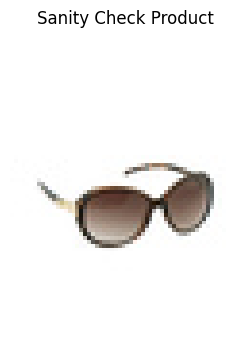

In [19]:
sample_row = work_df.iloc[0]

print("Sample product:")
print(sample_row["productDisplayName"])
print(sample_row["product_text"])

sample_text_embedding = get_clip_text_embedding(sample_row["product_text"])
sample_image_embedding = get_clip_image_embedding(sample_row["image_path"])
sample_caption = generate_blip_caption(sample_row["image_path"])

print(f"Text embedding shape: {sample_text_embedding.shape}")
print(f"Image embedding shape: {sample_image_embedding.shape}")
print(f"BLIP caption: {sample_caption}")

show_product(sample_row, title="Sanity Check Product")

In [21]:
QUERY_SYNONYMS = {
    "shirt": ["top", "casual shirt", "fashion shirt"],
    "tshirt": ["tee", "t-shirt", "casual top"],
    "shoe": ["footwear", "sneaker", "fashion shoe"],
    "jeans": ["denim", "pants", "casual jeans"],
    "watch": ["wrist watch", "accessory watch"],
    "bag": ["handbag", "fashion bag", "carry bag"],
    "dress": ["outfit", "fashion dress", "casual dress"]
}


def expand_query(query):
    query = query.strip().lower()
    expanded_queries = [query]

    for keyword, synonyms in QUERY_SYNONYMS.items():
        if keyword in query:
            expanded_queries.extend(
                [query.replace(keyword, synonym) for synonym in synonyms]
            )

    return list(dict.fromkeys(expanded_queries))


def get_query_embedding(query, use_expansion=True):
    queries = expand_query(query) if use_expansion else [query]
    embeddings = np.vstack([get_clip_text_embedding(text) for text in queries])
    combined_embedding = embeddings.mean(axis=0, keepdims=True)
    return l2_normalize(combined_embedding)[0], queries


def get_match_strength(score):
    if score >= 0.30:
        return "High match"
    if score >= 0.24:
        return "Medium match"
    return "Low match"


def build_search_reason(query, row, score):
    query_lower = query.lower()
    reasons = []

    if str(row.get("baseColour", "")).lower() in query_lower:
        reasons.append(f"color match: {row.get('baseColour', 'Unknown')}")
    if str(row.get("articleType", "")).lower() in query_lower:
        reasons.append(f"article match: {row.get('articleType', 'Unknown')}")
    if str(row.get("subCategory", "")).lower() in query_lower:
        reasons.append(f"subcategory match: {row.get('subCategory', 'Unknown')}")

    if not reasons:
        reasons.append(f"semantic similarity score: {score:.3f}")

    return " | ".join(reasons)


def reverse_product_search(query, top_k=6, use_expansion=True):
    query_embedding, expanded_queries = get_query_embedding(query, use_expansion=use_expansion)
    similarity_scores = image_embeddings @ query_embedding
    top_indices = np.argsort(similarity_scores)[::-1][:top_k]

    results = work_df.iloc[top_indices].copy().reset_index(drop=True)
    results["similarity_score"] = similarity_scores[top_indices]
    results["match_strength"] = results["similarity_score"].apply(get_match_strength)
    results["search_reason"] = results.apply(
        lambda row: build_search_reason(query, row, row["similarity_score"]),
        axis=1
    )

    return results, expanded_queries


def visualize_reverse_search_results(query, results, expanded_queries):
    cols = min(3, len(results))
    rows = int(np.ceil(len(results) / cols))
    plt.figure(figsize=(5 * cols, 5 * rows))

    for idx, (_, row) in enumerate(results.iterrows(), start=1):
        plt.subplot(rows, cols, idx)
        plt.imshow(load_image(row["image_path"]))
        plt.axis("off")
        plt.title(
            f"{row['productDisplayName']}\n"
            f"Score: {row['similarity_score']:.3f} | {row['match_strength']}\n"
            f"{row['search_reason']}",
            fontsize=10
        )

    plt.suptitle(
        f"Reverse Product Search\nQuery: {query}\nExpanded Queries: {expanded_queries}",
        fontsize=14,
        y=1.02
    )
    plt.tight_layout()
    plt.show()

,productDisplayName,masterCategory,subCategory,articleType,baseColour,similarity_score,match_strength,search_reason
0,Wills Lifestyle Women Blue Top,Apparel,Topwear,Tops,Blue,0.296099,Medium match,color match: Blue
1,Jealous 21 Women Teal Shirt,Apparel,Topwear,Shirts,Teal,0.292608,Medium match,semantic similarity score: 0.293
2,Wrangler Women Purple Shirt,Apparel,Topwear,Shirts,Purple,0.288722,Medium match,semantic similarity score: 0.289
3,Remanika Women Blue Top,Apparel,Topwear,Tops,Blue,0.288052,Medium match,color match: Blue
4,s.Oliver Women Blue Top,Apparel,Topwear,Tops,Blue,0.285639,Medium match,color match: Blue
5,French Connection Men Light Blue Shirt,Apparel,Topwear,Shirts,Blue,0.285175,Medium match,color match: Blue


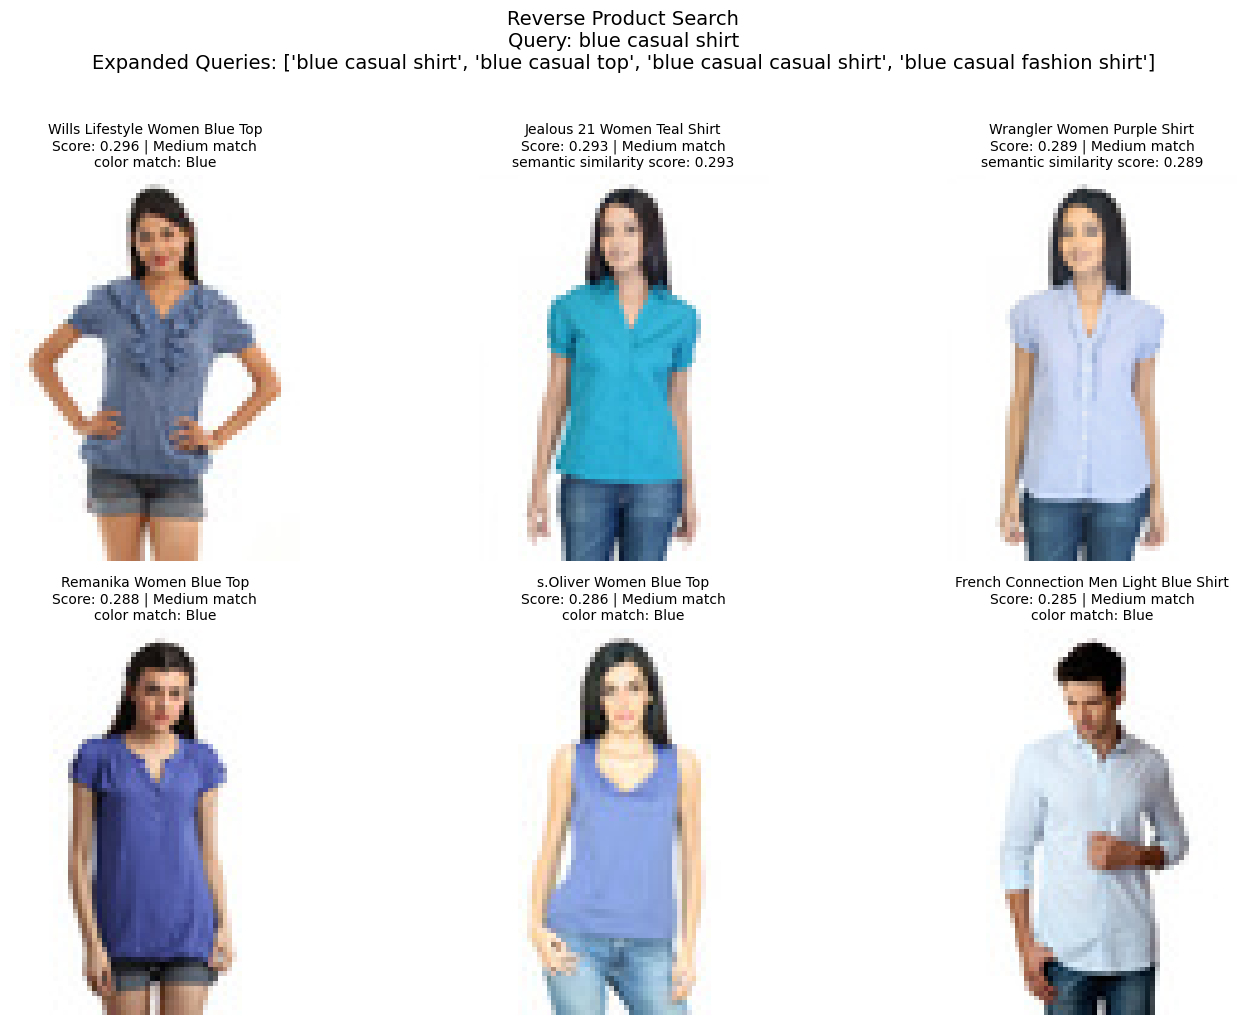

In [24]:
query = "blue casual shirt"

reverse_results, expanded_queries = reverse_product_search(
    query=query,
    top_k=6,
    use_expansion=True
)

display(
    reverse_results[
        [
            "productDisplayName",
            "masterCategory",
            "subCategory",
            "articleType",
            "baseColour",
            "similarity_score",
            "match_strength",
            "search_reason"
        ]
    ]
)

visualize_reverse_search_results(query, reverse_results, expanded_queries)

In [25]:
DUPLICATE_SIMILARITY_THRESHOLD = 0.92
duplicate_distance_threshold = 1 - DUPLICATE_SIMILARITY_THRESHOLD

duplicate_cluster_model = DBSCAN(
    eps=duplicate_distance_threshold,
    min_samples=2,
    metric="cosine"
)

duplicate_labels = duplicate_cluster_model.fit_predict(image_embeddings)
work_df["duplicate_cluster"] = duplicate_labels

duplicate_groups = (
    work_df[work_df["duplicate_cluster"] != -1]
    .groupby("duplicate_cluster")
    .size()
    .reset_index(name="group_size")
    .sort_values("group_size", ascending=False)
    .reset_index(drop=True)
)

unique_catalog_df = (
    work_df.sort_values("productDisplayName")
    .groupby("duplicate_cluster", dropna=False, as_index=False)
    .first()
)

singleton_df = work_df[work_df["duplicate_cluster"] == -1].copy()
clustered_unique_df = unique_catalog_df[unique_catalog_df["duplicate_cluster"] != -1].copy()
final_catalog_df = pd.concat([singleton_df, clustered_unique_df], ignore_index=True)

print(f"Total products in working set: {len(work_df):,}")
print(f"Duplicate groups found: {len(duplicate_groups):,}")
print(f"Products in duplicate groups: {(work_df['duplicate_cluster'] != -1).sum():,}")
print(f"Final catalog size after deduplication: {len(final_catalog_df):,}")

display(duplicate_groups.head(10))

Total products in working set: 3,000
Duplicate groups found: 74
Products in duplicate groups: 2,271
Final catalog size after deduplication: 803


,duplicate_cluster,group_size
0,3,947
1,2,545
2,6,217
3,1,109
4,14,74
5,0,68
6,7,52
7,18,26
8,11,17
9,15,14


Showing top duplicate cluster: 3


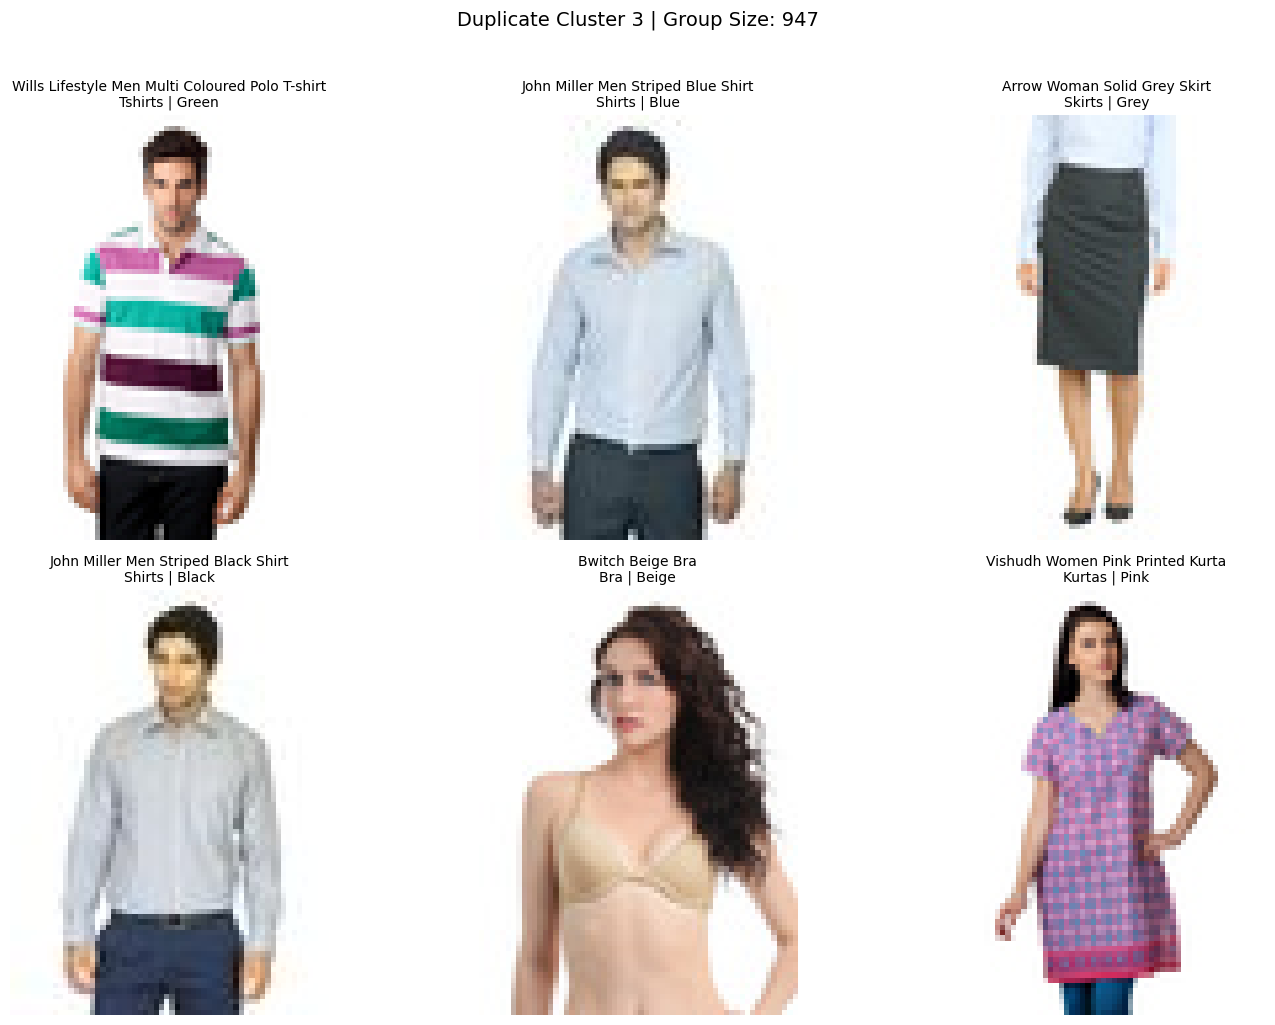

In [26]:
def visualize_duplicate_group(cluster_id, max_items=6):
    cluster_rows = (
        work_df[work_df["duplicate_cluster"] == cluster_id]
        .head(max_items)
        .reset_index(drop=True)
    )

    if cluster_rows.empty:
        print(f"No products found for cluster {cluster_id}")
        return

    cols = min(3, len(cluster_rows))
    rows = int(np.ceil(len(cluster_rows) / cols))
    plt.figure(figsize=(5 * cols, 5 * rows))

    for idx, (_, row) in enumerate(cluster_rows.iterrows(), start=1):
        plt.subplot(rows, cols, idx)
        plt.imshow(load_image(row["image_path"]))
        plt.axis("off")
        plt.title(
            f"{row['productDisplayName']}\n"
            f"{row['articleType']} | {row['baseColour']}",
            fontsize=10
        )

    plt.suptitle(
        f"Duplicate Cluster {cluster_id} | Group Size: {len(work_df[work_df['duplicate_cluster'] == cluster_id])}",
        fontsize=14,
        y=1.02
    )
    plt.tight_layout()
    plt.show()


top_cluster_id = int(duplicate_groups.iloc[0]["duplicate_cluster"])
print(f"Showing top duplicate cluster: {top_cluster_id}")
visualize_duplicate_group(top_cluster_id)

In [27]:
import re
from difflib import SequenceMatcher

def normalize_title(text):
    cleaned = re.sub(r"[^a-z0-9 ]+", " ", str(text).lower())
    return " ".join(cleaned.split())


def title_similarity(title_a, title_b):
    return SequenceMatcher(None, normalize_title(title_a), normalize_title(title_b)).ratio()


def build_refined_duplicate_clusters(df_input, embeddings, image_threshold=0.985, title_threshold=0.55):
    parent = list(range(len(df_input)))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        root_a = find(a)
        root_b = find(b)
        if root_a != root_b:
            parent[root_b] = root_a

    candidate_pairs = 0
    accepted_pairs = 0
    grouped = df_input.groupby(["gender", "masterCategory", "subCategory", "articleType"], dropna=False)

    for _, block in tqdm(grouped, total=grouped.ngroups, desc="Refining duplicate groups"):
        block_indices = block.index.to_list()
        if len(block_indices) < 2:
            continue

        block_embeddings = embeddings[block_indices]
        similarity_matrix = cosine_similarity(block_embeddings, block_embeddings)
        pair_rows, pair_cols = np.where(np.triu(similarity_matrix, k=1) >= image_threshold)
        candidate_pairs += len(pair_rows)

        for row_idx, col_idx in zip(pair_rows, pair_cols):
            idx_a = block_indices[row_idx]
            idx_b = block_indices[col_idx]

            color_a = str(df_input.iloc[idx_a].get("baseColour", "Unknown"))
            color_b = str(df_input.iloc[idx_b].get("baseColour", "Unknown"))
            same_color = color_a == color_b or "Unknown" in {color_a, color_b}

            title_a = df_input.iloc[idx_a].get("productDisplayName", "")
            title_b = df_input.iloc[idx_b].get("productDisplayName", "")
            name_similarity = title_similarity(title_a, title_b)
            image_similarity = similarity_matrix[row_idx, col_idx]

            if same_color and (name_similarity >= title_threshold or image_similarity >= 0.995):
                union(idx_a, idx_b)
                accepted_pairs += 1

    roots = [find(i) for i in range(len(df_input))]
    root_counts = pd.Series(roots).value_counts()
    root_to_cluster = {}
    cluster_labels = []
    next_cluster_id = 0

    for root in roots:
        if root_counts[root] < 2:
            cluster_labels.append(-1)
        else:
            if root not in root_to_cluster:
                root_to_cluster[root] = next_cluster_id
                next_cluster_id += 1
            cluster_labels.append(root_to_cluster[root])

    return np.array(cluster_labels), candidate_pairs, accepted_pairs


refined_labels, candidate_pairs, accepted_pairs = build_refined_duplicate_clusters(
    work_df,
    image_embeddings,
    image_threshold=0.985,
    title_threshold=0.55
)

work_df["refined_duplicate_cluster"] = refined_labels

refined_duplicate_groups = (
    work_df[work_df["refined_duplicate_cluster"] != -1]
    .groupby("refined_duplicate_cluster")
    .size()
    .reset_index(name="group_size")
    .sort_values("group_size", ascending=False)
    .reset_index(drop=True)
)

refined_representatives = (
    work_df[work_df["refined_duplicate_cluster"] != -1]
    .sort_values("productDisplayName")
    .groupby("refined_duplicate_cluster", as_index=False)
    .first()
)

refined_singletons = work_df[work_df["refined_duplicate_cluster"] == -1].copy()
refined_final_catalog_df = pd.concat([refined_singletons, refined_representatives], ignore_index=True)

print(f"Candidate image-similar pairs checked: {candidate_pairs:,}")
print(f"Accepted duplicate pairs after metadata checks: {accepted_pairs:,}")
print(f"Refined duplicate groups found: {len(refined_duplicate_groups):,}")
print(f"Products in refined duplicate groups: {(work_df['refined_duplicate_cluster'] != -1).sum():,}")
print(f"Refined catalog size after deduplication: {len(refined_final_catalog_df):,}")

display(refined_duplicate_groups.head(10))

Refining duplicate groups:   0%|          | 0/185 [00:00<?, ?it/s]

Candidate image-similar pairs checked: 20
Accepted duplicate pairs after metadata checks: 7
Refined duplicate groups found: 7
Products in refined duplicate groups: 14
Refined catalog size after deduplication: 2,993


,refined_duplicate_cluster,group_size
0,0,2
1,1,2
2,2,2
3,3,2
4,4,2
5,5,2
6,6,2


Showing refined duplicate cluster: 0


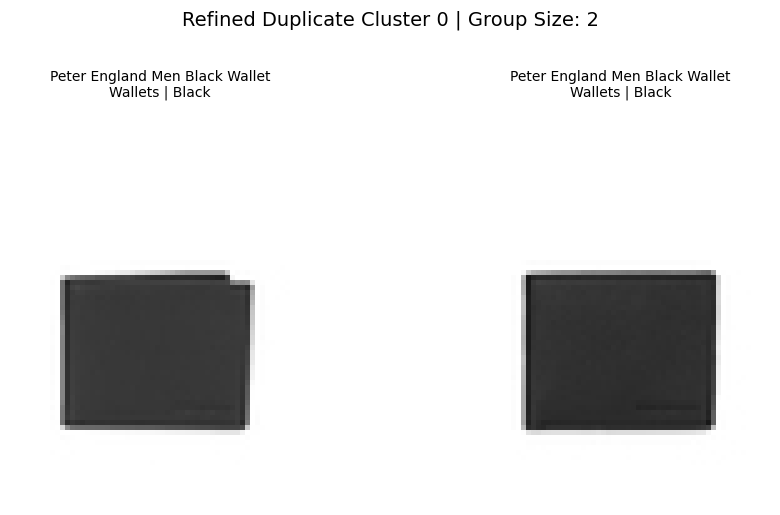

In [28]:
def visualize_refined_duplicate_group(cluster_id, max_items=6):
    cluster_rows = (
        work_df[work_df["refined_duplicate_cluster"] == cluster_id]
        .head(max_items)
        .reset_index(drop=True)
    )

    if cluster_rows.empty:
        print(f"No products found for refined cluster {cluster_id}")
        return

    cols = min(3, len(cluster_rows))
    rows = int(np.ceil(len(cluster_rows) / cols))
    plt.figure(figsize=(5 * cols, 5 * rows))

    for idx, (_, row) in enumerate(cluster_rows.iterrows(), start=1):
        plt.subplot(rows, cols, idx)
        plt.imshow(load_image(row["image_path"]))
        plt.axis("off")
        plt.title(
            f"{row['productDisplayName']}\n"
            f"{row['articleType']} | {row['baseColour']}",
            fontsize=10
        )

    plt.suptitle(
        f"Refined Duplicate Cluster {cluster_id} | Group Size: {len(work_df[work_df['refined_duplicate_cluster'] == cluster_id])}",
        fontsize=14,
        y=1.02
    )
    plt.tight_layout()
    plt.show()


top_refined_cluster_id = int(refined_duplicate_groups.iloc[0]["refined_duplicate_cluster"])
print(f"Showing refined duplicate cluster: {top_refined_cluster_id}")
visualize_refined_duplicate_group(top_refined_cluster_id)

In [29]:
COMPLEMENTARY_RULES = {
    "topwear": {
        "subcategories": ["Bottomwear"],
        "master_categories": ["Footwear", "Accessories"],
        "article_types": ["Jeans", "Trousers", "Leggings", "Shorts", "Skirts", "Casual Shoes", "Formal Shoes", "Flats", "Heels", "Watches", "Handbags", "Belts", "Sunglasses"]
    },
    "bottomwear": {
        "subcategories": ["Topwear"],
        "master_categories": ["Footwear", "Accessories"],
        "article_types": ["Shirts", "Tshirts", "Tops", "Kurtas", "Casual Shoes", "Formal Shoes", "Flats", "Heels", "Watches", "Handbags", "Belts"]
    },
    "dress": {
        "subcategories": [],
        "master_categories": ["Footwear", "Accessories"],
        "article_types": ["Heels", "Flats", "Sandals", "Handbags", "Watches", "Sunglasses"]
    },
    "shoes": {
        "subcategories": ["Topwear", "Bottomwear"],
        "master_categories": ["Accessories"],
        "article_types": ["Shirts", "Tshirts", "Tops", "Jeans", "Trousers", "Dresses", "Watches", "Belts", "Handbags"]
    },
    "watches": {
        "subcategories": ["Topwear", "Bottomwear"],
        "master_categories": ["Footwear"],
        "article_types": ["Shirts", "Tshirts", "Tops", "Jeans", "Trousers", "Kurtas", "Casual Shoes", "Formal Shoes"]
    },
    "bags": {
        "subcategories": ["Topwear", "Dress"],
        "master_categories": ["Footwear", "Accessories"],
        "article_types": ["Tops", "Shirts", "Dresses", "Kurtas", "Heels", "Flats", "Watches", "Sunglasses"]
    },
    "wallets": {
        "subcategories": ["Topwear", "Bottomwear"],
        "master_categories": ["Footwear", "Accessories"],
        "article_types": ["Shirts", "Tshirts", "Jeans", "Trousers", "Casual Shoes", "Belts", "Watches"]
    },
    "default": {
        "subcategories": ["Topwear", "Bottomwear", "Dress"],
        "master_categories": ["Footwear", "Accessories"],
        "article_types": ["Shirts", "Tshirts", "Tops", "Jeans", "Trousers", "Casual Shoes", "Watches", "Handbags", "Belts"]
    }
}

NEUTRAL_COLORS = {"Black", "White", "Grey", "Gray", "Brown", "Beige", "Navy Blue", "Silver", "Gold", "Tan", "Khaki"}
COOL_COLORS = {"Blue", "Navy Blue", "Teal", "Green", "Turquoise", "Purple"}
WARM_COLORS = {"Red", "Orange", "Pink", "Yellow", "Maroon", "Peach", "Coral"}


def get_complementary_rule(row):
    key = str(row.get("subCategory", "")).strip().lower()
    return COMPLEMENTARY_RULES.get(key, COMPLEMENTARY_RULES["default"])


def gender_compatible(source_gender, candidate_gender):
    source_gender = str(source_gender)
    candidate_gender = str(candidate_gender)
    if source_gender in {"Men", "Women", "Boys", "Girls"}:
        return candidate_gender in {source_gender, "Unisex"}
    return True


def colors_are_compatible(source_color, candidate_color):
    source_color = str(source_color)
    candidate_color = str(candidate_color)

    if source_color == candidate_color:
        return True
    if source_color in NEUTRAL_COLORS or candidate_color in NEUTRAL_COLORS:
        return True
    if source_color in COOL_COLORS and candidate_color in COOL_COLORS:
        return True
    if source_color in WARM_COLORS and candidate_color in WARM_COLORS:
        return True
    return False


def build_recommendation_queries(source_row, rule):
    gender = source_row.get("gender", "")
    usage = source_row.get("usage", "")
    color = source_row.get("baseColour", "")
    article_type = source_row.get("articleType", "")
    prompts = []

    for article in rule["article_types"][:6]:
        prompts.append(
            f"{article} for {gender} that complements a {color} {usage} {article_type}"
        )

    for subcategory in rule["subcategories"]:
        prompts.append(
            f"{subcategory} for {gender} to style with a {color} {usage} {article_type}"
        )

    return list(dict.fromkeys(prompts))


def build_recommendation_reason(source_row, candidate_row, rule):
    reasons = []

    if candidate_row.get("articleType") in rule["article_types"]:
        reasons.append(f"complementary type: {candidate_row.get('articleType')}")
    elif candidate_row.get("subCategory") in rule["subcategories"]:
        reasons.append(f"balances the outfit with {candidate_row.get('subCategory')}")

    if candidate_row.get("usage") == source_row.get("usage"):
        reasons.append(f"same usage: {candidate_row.get('usage')}")

    if colors_are_compatible(source_row.get("baseColour"), candidate_row.get("baseColour")):
        reasons.append(f"color harmony with {source_row.get('baseColour')}")

    if not reasons:
        reasons.append("strong style compatibility")

    return " | ".join(reasons)


def recommend_complementary_products(source_row, top_k=6):
    source_index = int(source_row.name)
    source_embedding = image_embeddings[source_index]
    rule = get_complementary_rule(source_row)

    strict_mask = work_df["id"] != source_row["id"]
    strict_mask &= work_df["gender"].apply(lambda gender: gender_compatible(source_row["gender"], gender))
    strict_mask &= work_df["articleType"] != source_row["articleType"]
    strict_mask &= work_df["usage"].isin([source_row["usage"], "Unknown"])
    strict_mask &= (
        work_df["articleType"].isin(rule["article_types"])
        | work_df["subCategory"].isin(rule["subcategories"])
        | work_df["masterCategory"].isin(rule["master_categories"])
    )

    candidate_indices = np.where(strict_mask.to_numpy())[0]

    if len(candidate_indices) < top_k:
        relaxed_mask = work_df["id"] != source_row["id"]
        relaxed_mask &= work_df["gender"].apply(lambda gender: gender_compatible(source_row["gender"], gender))
        relaxed_mask &= work_df["articleType"] != source_row["articleType"]
        relaxed_mask &= (
            work_df["articleType"].isin(rule["article_types"])
            | work_df["subCategory"].isin(rule["subcategories"])
            | work_df["masterCategory"].isin(rule["master_categories"])
        )
        candidate_indices = np.where(relaxed_mask.to_numpy())[0]

    recommendation_queries = build_recommendation_queries(source_row, rule)
    query_embeddings = np.vstack([get_clip_text_embedding(query) for query in recommendation_queries])
    combined_query_embedding = l2_normalize(query_embeddings.mean(axis=0, keepdims=True))[0]

    candidate_embeddings = image_embeddings[candidate_indices]
    semantic_scores = candidate_embeddings @ combined_query_embedding
    source_similarity = candidate_embeddings @ source_embedding

    results = work_df.iloc[candidate_indices].copy().reset_index(drop=True)
    results["semantic_score"] = semantic_scores
    results["same_usage_bonus"] = (results["usage"] == source_row["usage"]).astype(float) * 0.05
    results["color_bonus"] = results["baseColour"].apply(
        lambda color: 0.04 if colors_are_compatible(source_row["baseColour"], color) else 0.0
    )
    results["target_bonus"] = results.apply(
        lambda row: 0.08 if row["articleType"] in rule["article_types"]
        else (0.06 if row["subCategory"] in rule["subcategories"]
        else (0.04 if row["masterCategory"] in rule["master_categories"] else 0.0)),
        axis=1
    )
    results["visual_similarity_penalty"] = source_similarity * 0.03
    results["recommendation_score"] = (
        results["semantic_score"]
        + results["same_usage_bonus"]
        + results["color_bonus"]
        + results["target_bonus"]
        - results["visual_similarity_penalty"]
    )
    results["recommendation_reason"] = results.apply(
        lambda row: build_recommendation_reason(source_row, row, rule),
        axis=1
    )

    results = results.sort_values("recommendation_score", ascending=False).head(top_k).reset_index(drop=True)
    return results, recommendation_queries, rule


def visualize_recommendations(source_row, recommendation_results):
    cols = min(3, len(recommendation_results) + 1)
    rows = int(np.ceil((len(recommendation_results) + 1) / cols))
    plt.figure(figsize=(5 * cols, 5 * rows))

    plt.subplot(rows, cols, 1)
    plt.imshow(load_image(source_row["image_path"]))
    plt.axis("off")
    plt.title(f"Input Product\n{source_row['productDisplayName']}", fontsize=11)

    for idx, (_, row) in enumerate(recommendation_results.iterrows(), start=2):
        plt.subplot(rows, cols, idx)
        plt.imshow(load_image(row["image_path"]))
        plt.axis("off")
        plt.title(
            f"{row['productDisplayName']}\n"
            f"Score: {row['recommendation_score']:.3f}\n"
            f"{row['recommendation_reason']}",
            fontsize=9
        )

    plt.suptitle("Complementary Product Recommendations", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


Input product for recommendation:
Mr.Men Boys Blazing Yellow T-shirt
name: Mr.Men Boys Blazing Yellow T-shirt | gender: Boys | category: Apparel | subcategory: Topwear | article type: Tshirts | color: Yellow | season: Summer | usage: Casual

Generated recommendation prompts:
- Jeans for Boys that complements a Yellow Casual Tshirts
- Trousers for Boys that complements a Yellow Casual Tshirts
- Leggings for Boys that complements a Yellow Casual Tshirts
- Shorts for Boys that complements a Yellow Casual Tshirts
- Skirts for Boys that complements a Yellow Casual Tshirts
- Casual Shoes for Boys that complements a Yellow Casual Tshirts
- Bottomwear for Boys to style with a Yellow Casual Tshirts


,productDisplayName,masterCategory,subCategory,articleType,baseColour,usage,recommendation_score,recommendation_reason
0,Puma Unisex Lo Punk Black Yellow Shoe,Footwear,Shoes,Casual Shoes,Black,Casual,0.432685,complementary type: Casual Shoes | same usage:...
1,Puma Unisex Black Shoes,Footwear,Shoes,Casual Shoes,Black,Casual,0.424759,complementary type: Casual Shoes | same usage:...
2,Puma Unisex Black Shoes,Footwear,Shoes,Casual Shoes,Black,Casual,0.408027,complementary type: Casual Shoes | same usage:...
3,Lino Perros Unisex Beige Sling Bag,Accessories,Bags,Handbags,Beige,Casual,0.388749,complementary type: Handbags | same usage: Cas...
4,Warner Bros Kids Unisex TJ Check Skate Black C...,Footwear,Shoes,Casual Shoes,Black,Casual,0.387801,complementary type: Casual Shoes | same usage:...
5,Gini and Jony Kids Unisex Blue Jeans,Apparel,Bottomwear,Jeans,Blue,Casual,0.384284,complementary type: Jeans | same usage: Casual


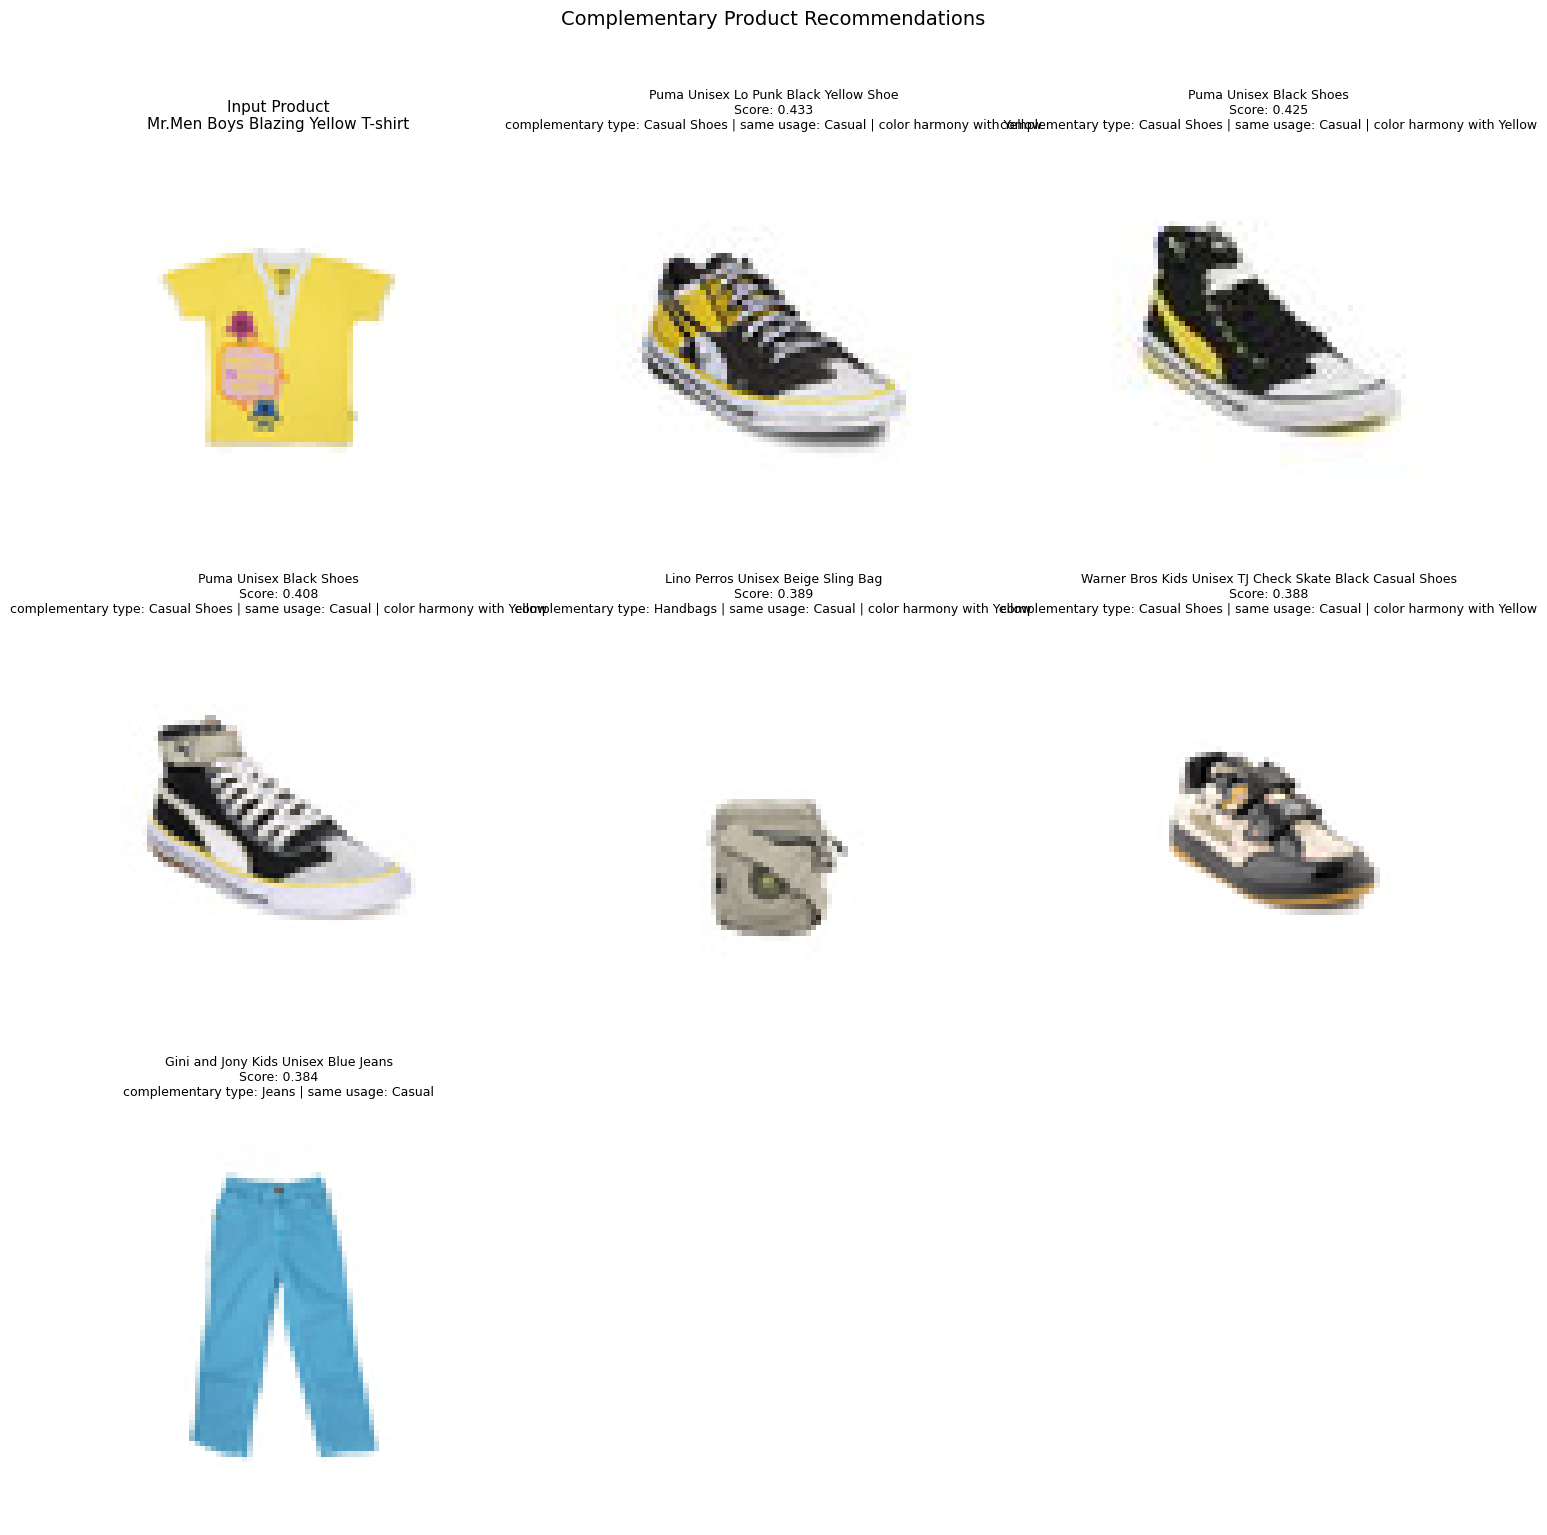

In [30]:
recommendation_source_row = work_df[
    work_df["subCategory"].isin(["Topwear", "Dress", "Shoes", "Bags", "Wallets"])
].iloc[0]

print("Input product for recommendation:")
print(recommendation_source_row["productDisplayName"])
print(recommendation_source_row["product_text"])

recommendation_results, recommendation_queries, recommendation_rule = recommend_complementary_products(
    recommendation_source_row,
    top_k=6
)

print("\nGenerated recommendation prompts:")
for prompt in recommendation_queries:
    print("-", prompt)

display(
    recommendation_results[
        [
            "productDisplayName",
            "masterCategory",
            "subCategory",
            "articleType",
            "baseColour",
            "usage",
            "recommendation_score",
            "recommendation_reason"
        ]
    ]
)

visualize_recommendations(recommendation_source_row, recommendation_results)

,productDisplayName,articleType,baseColour,usage,recommendation_score,recommendation_reason
0,Puma Unisex Lo Punk Black Yellow Shoe,Casual Shoes,Black,Casual,0.433,complementary type: Casual Shoes | same usage: Casual | color harmony with Yellow
1,Puma Unisex Black Shoes,Casual Shoes,Black,Casual,0.425,complementary type: Casual Shoes | same usage: Casual | color harmony with Yellow
2,Puma Unisex Black Shoes,Casual Shoes,Black,Casual,0.408,complementary type: Casual Shoes | same usage: Casual | color harmony with Yellow
3,Lino Perros Unisex Beige Sling Bag,Handbags,Beige,Casual,0.389,complementary type: Handbags | same usage: Casual | color harmony with Yellow
4,Warner Bros Kids Unisex TJ Check Skate Black Casual Shoes,Casual Shoes,Black,Casual,0.388,complementary type: Casual Shoes | same usage: Casual | color harmony with Yellow
5,Gini and Jony Kids Unisex Blue Jeans,Jeans,Blue,Casual,0.384,complementary type: Jeans | same usage: Casual


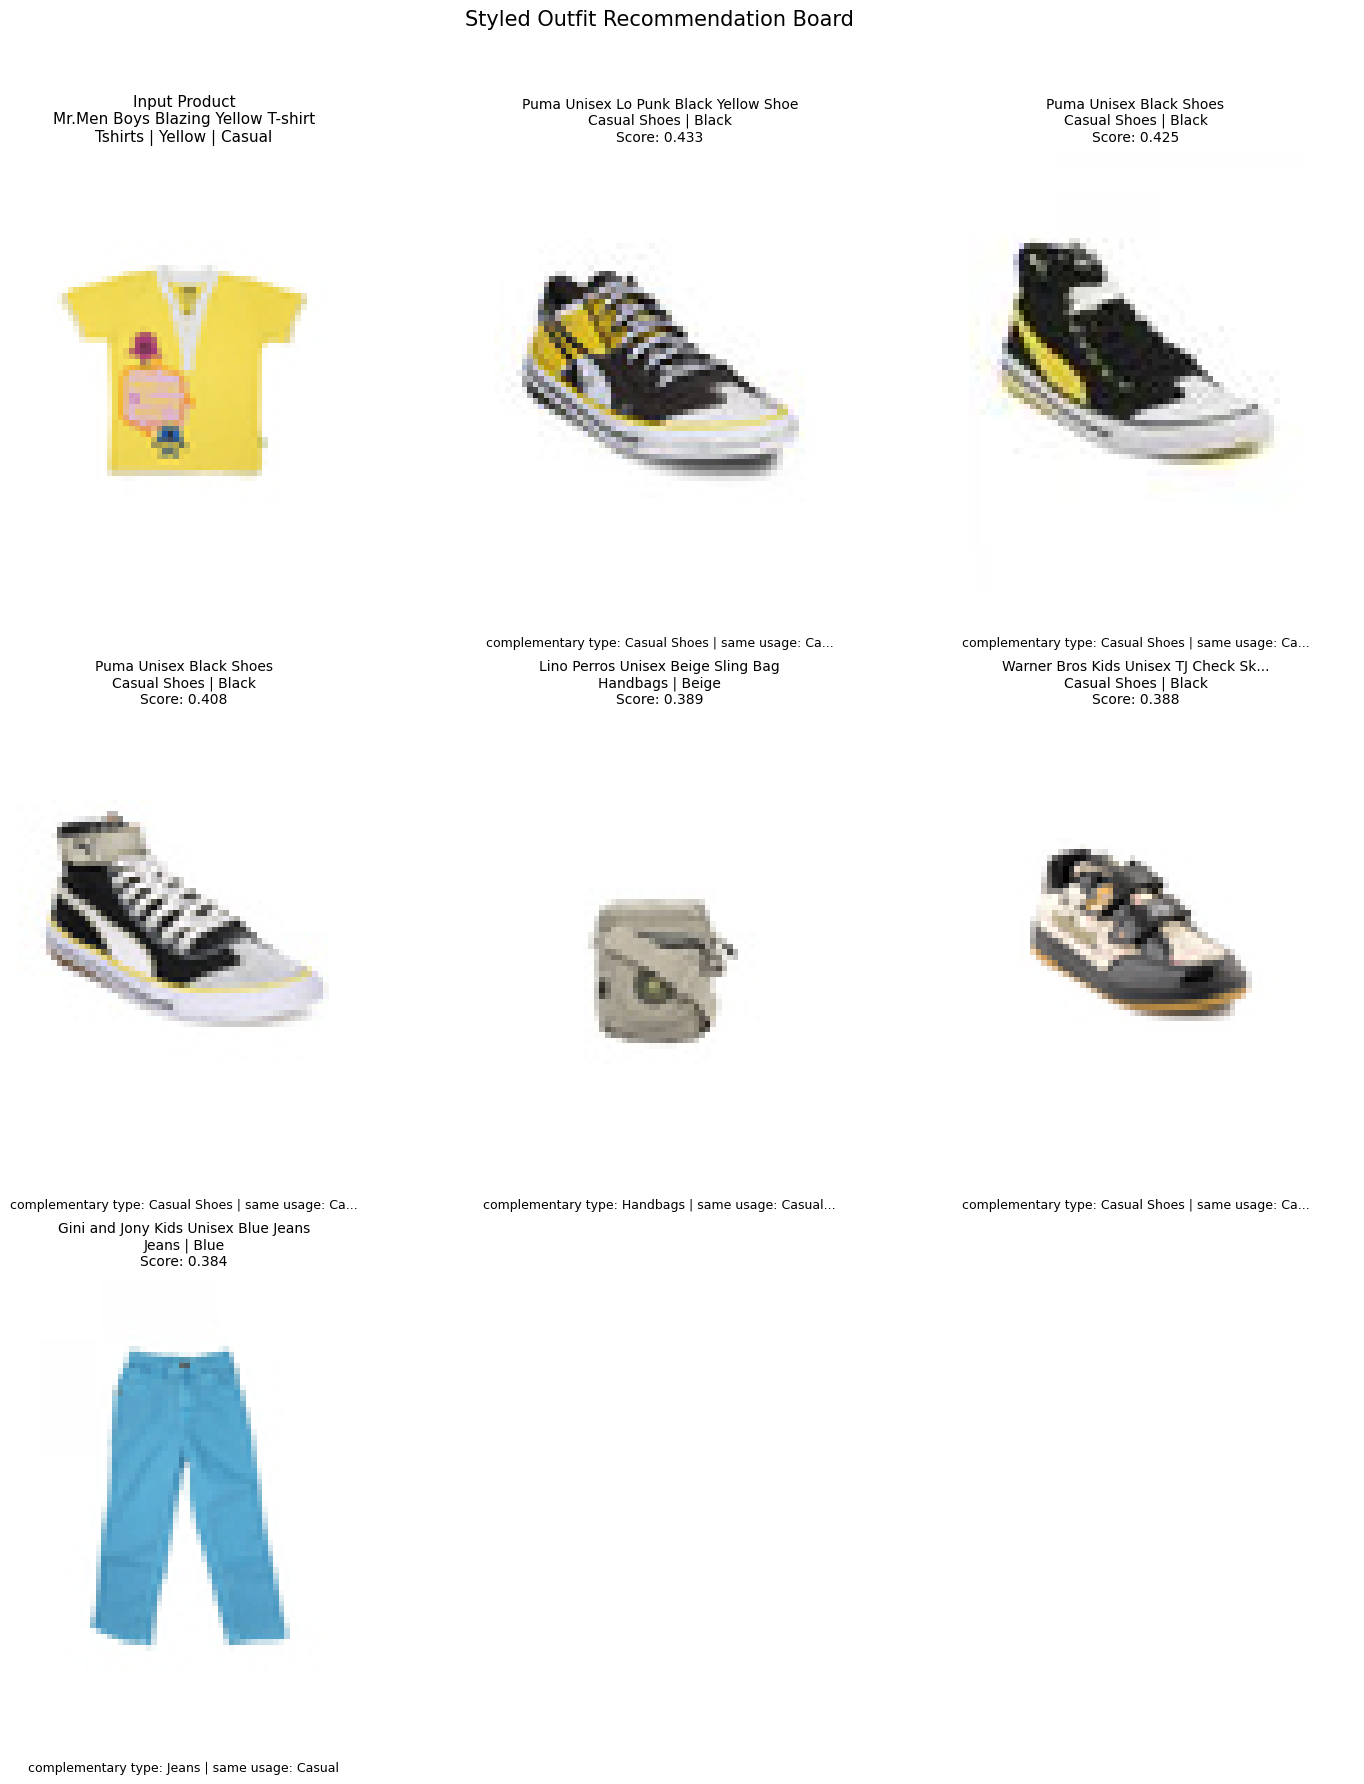

In [31]:
def shorten_label(text, max_len=38):
    text = str(text)
    return text if len(text) <= max_len else text[: max_len - 3] + "..."


def show_recommendation_board(source_row, recommendation_results):
    summary_columns = [
        "productDisplayName", "articleType", "baseColour", "usage",
        "recommendation_score", "recommendation_reason"
    ]
    display(
        recommendation_results[summary_columns]
        .style
        .format({"recommendation_score": "{:.3f}"})
        .set_caption("Recommendation Summary")
    )

    cols = min(3, len(recommendation_results) + 1)
    rows = int(np.ceil((len(recommendation_results) + 1) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.8 * cols, 5.8 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    axes[0].imshow(load_image(source_row["image_path"]))
    axes[0].set_title(
        "Input Product\n"
        f"{shorten_label(source_row['productDisplayName'], 34)}\n"
        f"{source_row['articleType']} | {source_row['baseColour']} | {source_row['usage']}",
        fontsize=11
    )

    for idx, (_, row) in enumerate(recommendation_results.iterrows(), start=1):
        axes[idx].imshow(load_image(row["image_path"]))
        axes[idx].set_title(
            f"{shorten_label(row['productDisplayName'])}\n"
            f"{row['articleType']} | {row['baseColour']}\n"
            f"Score: {row['recommendation_score']:.3f}",
            fontsize=10
        )
        axes[idx].text(
            0.5,
            -0.10,
            shorten_label(row["recommendation_reason"], 52),
            transform=axes[idx].transAxes,
            ha="center",
            va="top",
            fontsize=9
        )

    plt.suptitle("Styled Outfit Recommendation Board", fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()


show_recommendation_board(recommendation_source_row, recommendation_results)

,productDisplayName,articleType,baseColour,similarity_score,match_strength,search_reason
0,Wills Lifestyle Women Blue Top,Tops,Blue,0.296,Medium match,color match: Blue
1,Jealous 21 Women Teal Shirt,Shirts,Teal,0.293,Medium match,semantic similarity score: 0.293
2,Wrangler Women Purple Shirt,Shirts,Purple,0.289,Medium match,semantic similarity score: 0.289
3,Remanika Women Blue Top,Tops,Blue,0.288,Medium match,color match: Blue
4,s.Oliver Women Blue Top,Tops,Blue,0.286,Medium match,color match: Blue
5,French Connection Men Light Blue Shirt,Shirts,Blue,0.285,Medium match,color match: Blue


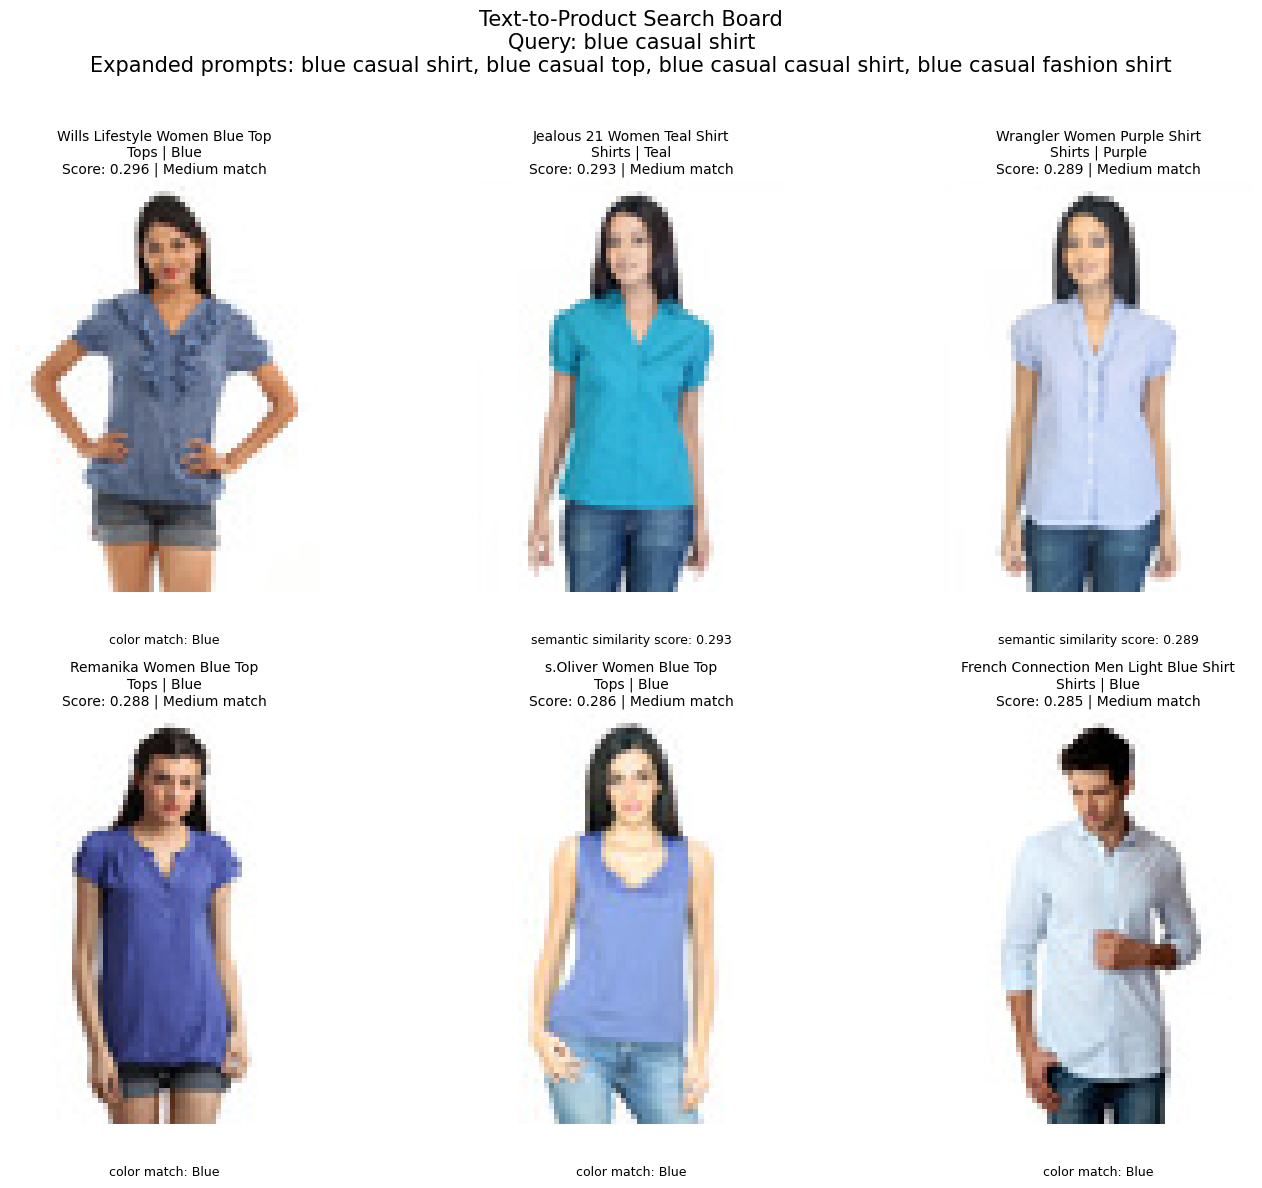

In [32]:
def show_search_results_board(query, results, expanded_queries):
    summary_columns = [
        "productDisplayName", "articleType", "baseColour",
        "similarity_score", "match_strength", "search_reason"
    ]
    display(
        results[summary_columns]
        .style
        .format({"similarity_score": "{:.3f}"})
        .set_caption(f"Search Results for: {query}")
    )

    cols = min(3, len(results))
    rows = int(np.ceil(len(results) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.8 * cols, 5.8 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for idx, (_, row) in enumerate(results.iterrows()):
        axes[idx].imshow(load_image(row["image_path"]))
        axes[idx].set_title(
            f"{shorten_label(row['productDisplayName'])}\n"
            f"{row['articleType']} | {row['baseColour']}\n"
            f"Score: {row['similarity_score']:.3f} | {row['match_strength']}",
            fontsize=10
        )
        axes[idx].text(
            0.5,
            -0.10,
            shorten_label(row["search_reason"], 52),
            transform=axes[idx].transAxes,
            ha="center",
            va="top",
            fontsize=9
        )

    expanded_query_text = ", ".join(expanded_queries[:4])
    if len(expanded_queries) > 4:
        expanded_query_text += ", ..."

    plt.suptitle(
        "Text-to-Product Search Board\n"
        f"Query: {query}\n"
        f"Expanded prompts: {expanded_query_text}",
        fontsize=15,
        y=1.02
    )
    plt.tight_layout()
    plt.show()


show_search_results_board(query, reverse_results, expanded_queries)

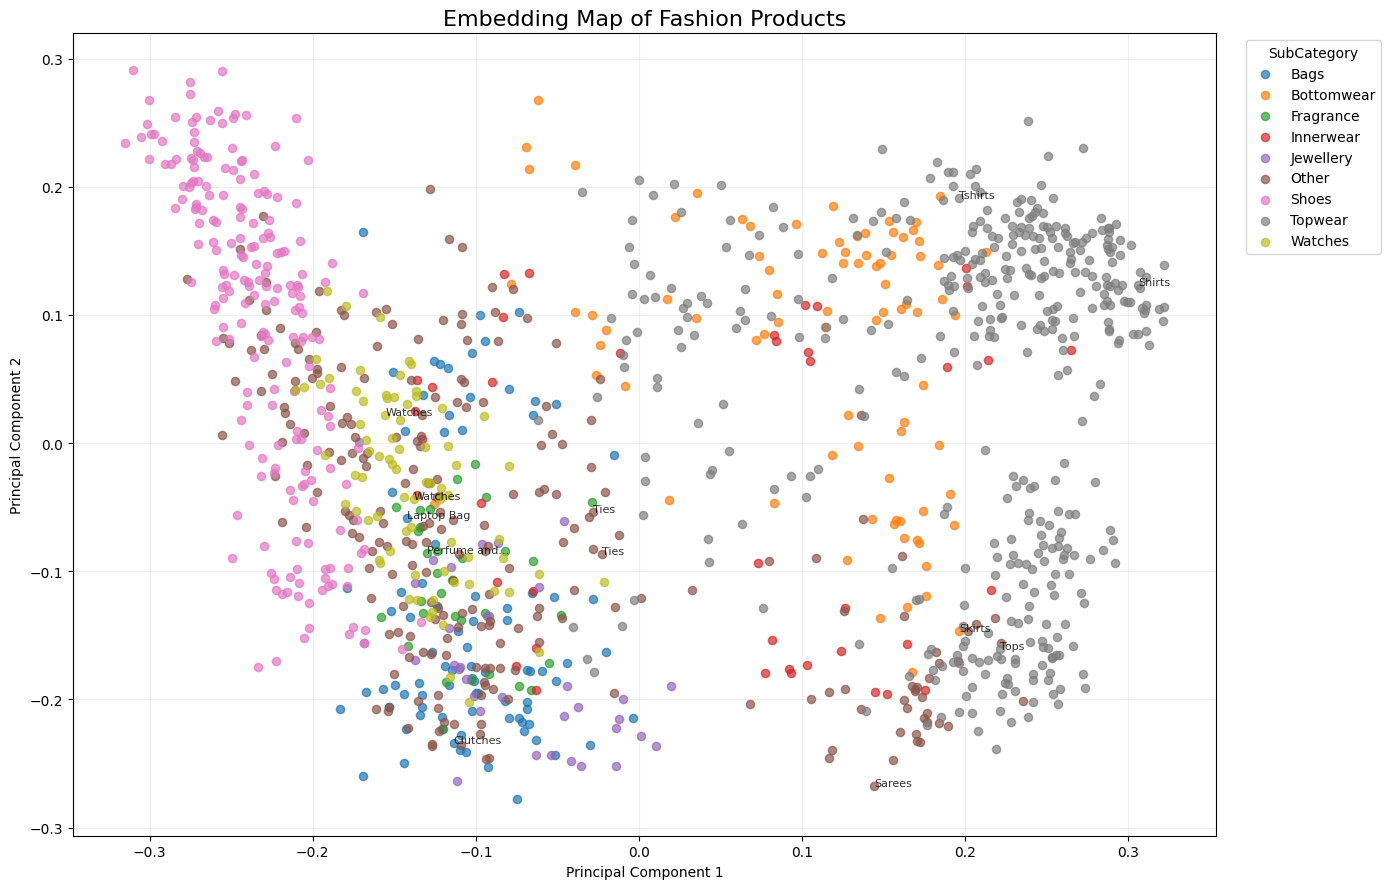

PCA explained variance ratio: 0.199


In [33]:
plot_sample_size = min(1200, len(work_df))
plot_indices = np.random.RandomState(42).choice(len(work_df), size=plot_sample_size, replace=False)

plot_df = work_df.iloc[plot_indices].copy().reset_index(drop=True)
plot_embeddings = image_embeddings[plot_indices]

pca = PCA(n_components=2, random_state=42)
embedding_map = pca.fit_transform(plot_embeddings)

plot_df["pca_x"] = embedding_map[:, 0]
plot_df["pca_y"] = embedding_map[:, 1]

top_categories = plot_df["subCategory"].value_counts().head(8).index.tolist()
plot_df["plot_group"] = plot_df["subCategory"].where(
    plot_df["subCategory"].isin(top_categories),
    other="Other"
)

plt.figure(figsize=(14, 9))

for group_name in sorted(plot_df["plot_group"].unique()):
    group_rows = plot_df[plot_df["plot_group"] == group_name]
    plt.scatter(
        group_rows["pca_x"],
        group_rows["pca_y"],
        s=35,
        alpha=0.7,
        label=group_name
    )

for _, row in plot_df.sample(n=min(12, len(plot_df)), random_state=42).iterrows():
    plt.text(
        row["pca_x"],
        row["pca_y"],
        shorten_label(row["articleType"], 14),
        fontsize=8,
        alpha=0.8
    )

plt.title("Embedding Map of Fashion Products", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="SubCategory", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.3f}")

In [34]:
summary_rows = [
    ["Products indexed", f"{len(work_df):,}"],
    ["Embedding dimension", image_embeddings.shape[1]],
    ["Search demo query", query],
    ["Top search result", reverse_results.iloc[0]["productDisplayName"]],
    ["Refined duplicate groups", f"{len(refined_duplicate_groups):,}"],
    ["Products in duplicate groups", f"{(work_df['refined_duplicate_cluster'] != -1).sum():,}"],
    ["Catalog size after deduplication", f"{len(refined_final_catalog_df):,}"],
    ["Recommendation input", recommendation_source_row["productDisplayName"]],
    ["Top recommendation", recommendation_results.iloc[0]["productDisplayName"]],
    ["PCA sample size", f"{len(plot_df):,}"],
    ["PCA explained variance", f"{pca.explained_variance_ratio_.sum():.3f}"]
]

summary_df = pd.DataFrame(summary_rows, columns=["Metric", "Value"])
display(summary_df)

print("Project summary complete.")

,Metric,Value
0,Products indexed,"3,000"
1,Embedding dimension,512
2,Search demo query,blue casual shirt
3,Top search result,Wills Lifestyle Women Blue Top
4,Refined duplicate groups,7
5,Products in duplicate groups,14
6,Catalog size after deduplication,"2,993"
7,Recommendation input,Mr.Men Boys Blazing Yellow T-shirt
8,Top recommendation,Puma Unisex Lo Punk Black Yellow Shoe
9,PCA sample size,"1,200"


Project summary complete.
